In [2]:
import pandas as pd

df = pd.read_csv("../data/raw/predictive_maintenance.csv")

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  str    
dtypes: float64(3), int64(4), str(3)
memory usage: 781.4 KB


In [5]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


In [6]:
df["Target"].value_counts()

Target
0    9661
1     339
Name: count, dtype: int64

In [7]:
df["Target"].value_counts(normalize=True)*100

Target
0    96.61
1     3.39
Name: proportion, dtype: float64

In [8]:
df["Failure Type"].value_counts()

Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

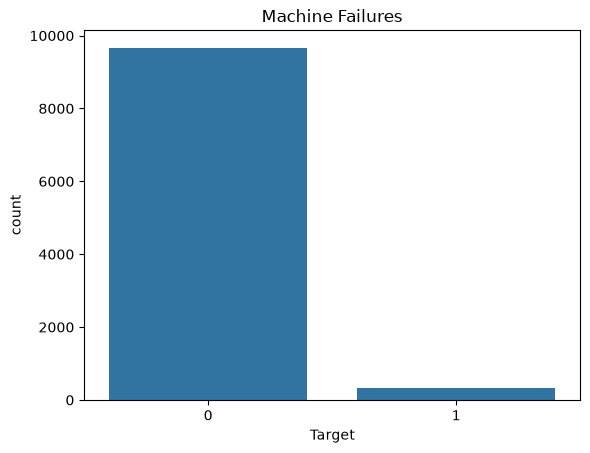

In [11]:
sns.countplot(data=df, x="Target")

plt.title("Machine Failures")
plt.show()

In [12]:
df.groupby("Target")["Tool wear [min]"].mean()

Target
0    106.693717
1    143.781711
Name: Tool wear [min], dtype: float64

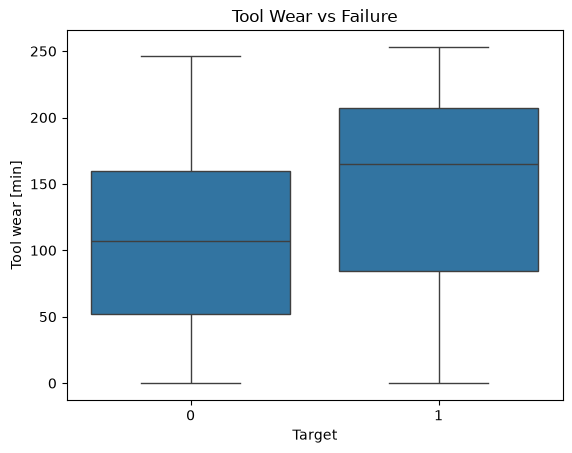

In [13]:
sns.boxplot(
    data=df,
    x="Target",
    y="Tool wear [min]",
)

plt.title("Tool Wear vs Failure")
plt.show()

In [15]:
df.groupby("Target")["Torque [Nm]"].mean()

Target
0    39.629655
1    50.168142
Name: Torque [Nm], dtype: float64

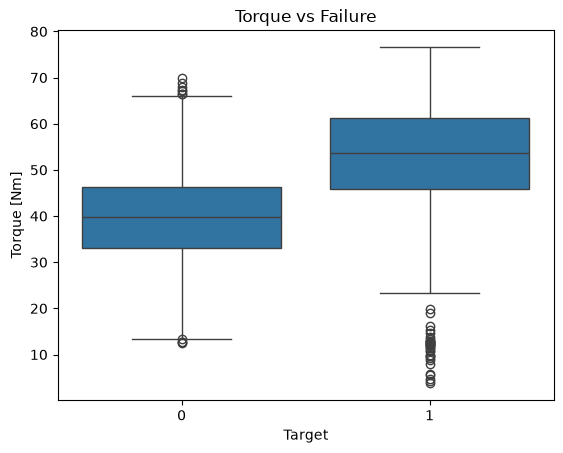

In [16]:
sns.boxplot(
    data=df,
    x="Target",
    y="Torque [Nm]"
)

plt.title("Torque vs Failure")
plt.show()

In [24]:
df.groupby("Target")["Rotational speed [rpm]"].mean()

Target
0    1540.260014
1    1496.486726
Name: Rotational speed [rpm], dtype: float64

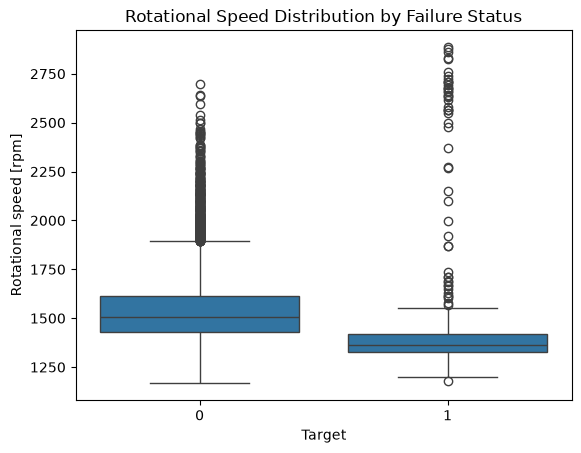

In [26]:
sns.boxplot(
    data=df,
    x="Target",
    y="Rotational speed [rpm]"
)

plt.title("Rotational Speed Distribution by Failure Status")
plt.show()

In [27]:
df.groupby("Target")["Process temperature [K]"].mean()

Target
0    309.995570
1    310.290265
Name: Process temperature [K], dtype: float64

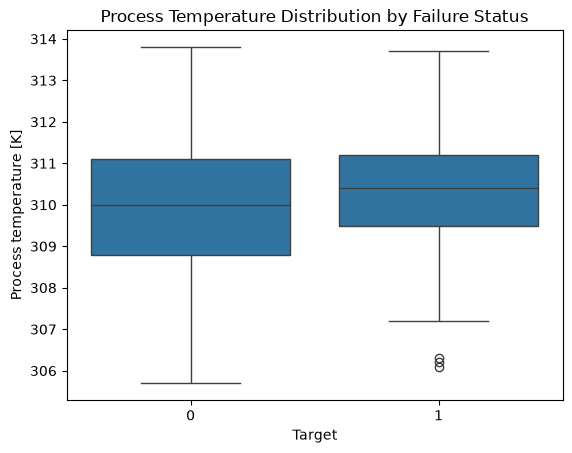

In [28]:
sns.boxplot(data=df, x="Target", y="Process temperature [K]")
plt.title("Process Temperature Distribution by Failure Status")
plt.show()

In [22]:
df.groupby("Target")["Air temperature [K]"].mean()

Target
0    299.973999
1    300.886431
Name: Air temperature [K], dtype: float64

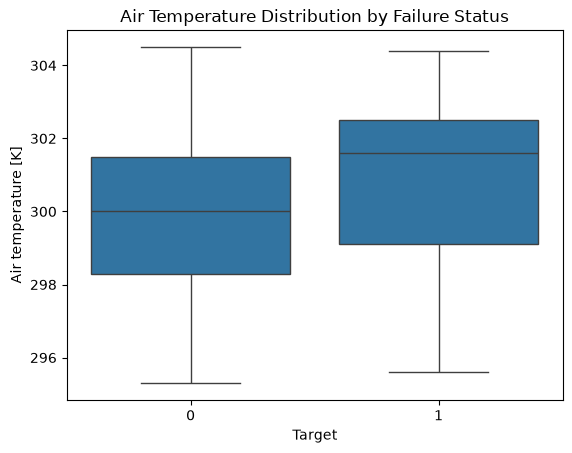

In [23]:
sns.boxplot(
    data=df,
    x="Target",
    y="Air temperature [K]"
)
plt.title("Air Temperature Distribution by Failure Status")
plt.show()


In [29]:
df.groupby("Target")["Torque [Nm]"].describe()

,count,mean,std,min,25%,50%,75%,max
Target,,,,,,,,
0,9661.0,39.629655,9.472080,12.6,33.10,39.9,46.3,70.0
1,339.0,50.168142,16.374498,3.8,45.95,53.7,61.2,76.6


In [31]:
numerical_cols = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

for col in numerical_cols:
    print(f"\n{col}")
    print(df.groupby("Target")[col].mean())


Air temperature [K]
Target
0    299.973999
1    300.886431
Name: Air temperature [K], dtype: float64

Process temperature [K]
Target
0    309.995570
1    310.290265
Name: Process temperature [K], dtype: float64

Rotational speed [rpm]
Target
0    1540.260014
1    1496.486726
Name: Rotational speed [rpm], dtype: float64

Torque [Nm]
Target
0    39.629655
1    50.168142
Name: Torque [Nm], dtype: float64

Tool wear [min]
Target
0    106.693717
1    143.781711
Name: Tool wear [min], dtype: float64


In [32]:
corr = df.corr(numeric_only=True)

corr["Target"].sort_values(ascending=False)

Target                     1.000000
Torque [Nm]                0.191321
Tool wear [min]            0.105448
Air temperature [K]        0.082556
Process temperature [K]    0.035946
UDI                       -0.022892
Rotational speed [rpm]    -0.044188
Name: Target, dtype: float64

In [33]:
features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

x = df[features]
y = df["Target"]

In [34]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [35]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

model.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [36]:
predictions = model.predict(x_test)

In [37]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1939
           1       0.82      0.59      0.69        61

    accuracy                           0.98      2000
   macro avg       0.90      0.79      0.84      2000
weighted avg       0.98      0.98      0.98      2000



In [38]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
3,Torque [Nm],0.320955
2,Rotational speed [rpm],0.214712
0,Air temperature [K],0.161565
4,Tool wear [min],0.153936
1,Process temperature [K],0.148831


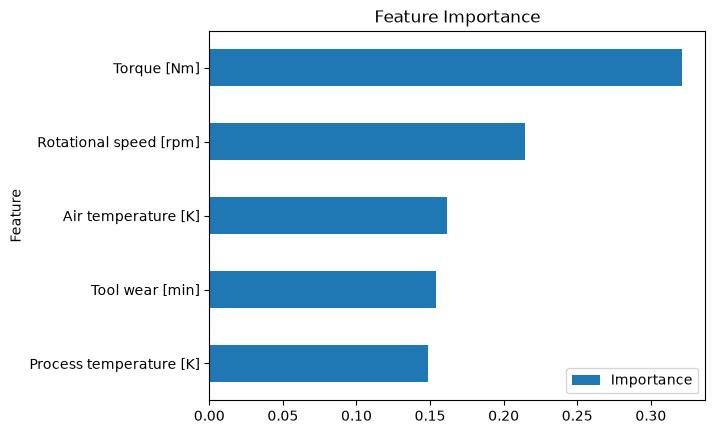

In [39]:
importance.sort_values(
    by="Importance",
    ascending=True
).plot(
    x="Feature",
    y="Importance",
    kind="barh"
)

plt.title("Feature Importance")
plt.show()

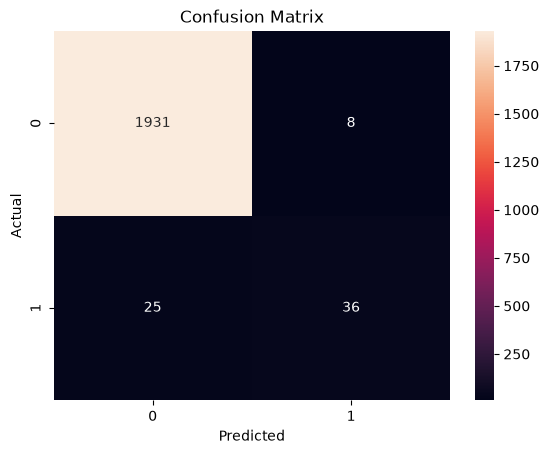

In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, predictions)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()